# Fase 7: Metodi di Ensemble per il Miglioramento della Predizione

In questo notebook si implementano ed analizzano due tecniche di **Ensemble Learning** per verificare se l'unione dei singoli classificatori possa superare le performance del miglior modello singolo (la Regressione Logistica):
1. **Voting Classifier (Soft Voting)**: Combinazione delle probabilità predette da tutti i 5 modelli di base (Regressione Logistica, Random Forest, XGBoost, LightGBM, SVM) tramite media semplice delle probabilità.
2. **Stacking Classifier**: Utilizzo dei modelli di base come predittori di primo livello. Le loro probabilità di classe vengono usate come input per un modello di secondo livello (Meta-Classificatore, in questo caso una Regressione Logistica semplice con pesi bilanciati) che impara a combinare al meglio le decisioni.

La valutazione di entrambi i metodi viene effettuata sul Test Set isolato per un confronto con il miglior modello singolo.

In [1]:
# Importazione delle librerie necessarie
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Impostazione dello stile grafico di Seaborn
sns.set_theme(style="whitegrid")

In [2]:
# Caricamento del dataset nella configurazione Clean + Aug
CARTELLA_DATI = "../Training/Clean/Aug/"

X_train = pd.read_csv(os.path.join(CARTELLA_DATI, "X_train.csv"))
X_test = pd.read_csv(os.path.join(CARTELLA_DATI, "X_test.csv"))
y_train = pd.read_csv(os.path.join(CARTELLA_DATI, "Y_train.csv")).squeeze().values.ravel()
y_test = pd.read_csv(os.path.join(CARTELLA_DATI, "Y_test.csv")).squeeze().values.ravel()

print(f"📦 Caricamento dati completato! Train: {X_train.shape}, Test: {X_test.shape}")

# Caricamento dei modelli pre-addestrati da utilizzare come base dell'ensemble
modello_lr = joblib.load(os.path.join(CARTELLA_DATI, "logistic_regression.joblib"))
modello_rf = joblib.load(os.path.join(CARTELLA_DATI, "random_forest.joblib"))
modello_xgb = joblib.load(os.path.join(CARTELLA_DATI, "xgboost.joblib"))
modello_lgb = joblib.load(os.path.join(CARTELLA_DATI, "lightgbm.joblib"))
modello_svm = joblib.load(os.path.join(CARTELLA_DATI, "svm.joblib"))

print("✅ Modelli di base caricati correttamente!")

📦 Caricamento dati completato! Train: (4312, 15), Test: (848, 15)
✅ Modelli di base caricati correttamente!


In [3]:
# Definizione dei stimatori base per il Voting Classifier
stimatori_base = [
    ('lr', modello_lr),
    ('rf', modello_rf),
    ('xgb', modello_xgb),
    ('lgb', modello_lgb),
    ('svm', modello_svm)
]

# Creazione e addestramento del Voting Classifier (Soft Voting)
print("🚀 Addestramento del Voting Classifier (Soft Voting)...")
modello_voting = VotingClassifier(estimators=stimatori_base, voting='soft', n_jobs=-1)
modello_voting.fit(X_train, y_train)

# Predizioni sul Test Set
predizioni_voting = modello_voting.predict(X_test)
try:
    probabilita_voting = modello_voting.predict_proba(X_test)[:, 1]
    auc_voting = roc_auc_score(y_test, probabilita_voting)
except Exception:
    auc_voting = np.nan

# Calcolo delle metriche per il Voting Classifier
metriche_voting = {
    'Accuracy': accuracy_score(y_test, predizioni_voting),
    'Balanced_Accuracy': balanced_accuracy_score(y_test, predizioni_voting),
    'Precision': precision_score(y_test, predizioni_voting, zero_division=0),
    'Recall': recall_score(y_test, predizioni_voting),
    'F1-Score': f1_score(y_test, predizioni_voting),
    'ROC-AUC': auc_voting
}

print("✅ Addestramento e valutazione Voting Classifier completati!")

🚀 Addestramento del Voting Classifier (Soft Voting)...
✅ Addestramento e valutazione Voting Classifier completati!


In [4]:
# Creazione e addestramento del Stacking Classifier
# Utilizzo di una Regressione Logistica semplice come Meta-Classificatore final_estimator
print("🚀 Addestramento del Stacking Classifier (Meta-modello: Regressione Logistica)...")
meta_classificatore = LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42)

modello_stacking = StackingClassifier(
    estimators=stimatori_base,
    final_estimator=meta_classificatore,
    cv=5,
    n_jobs=-1
)
modello_stacking.fit(X_train, y_train)

# Predizioni sul Test Set
predizioni_stacking = modello_stacking.predict(X_test)
try:
    probabilita_stacking = modello_stacking.predict_proba(X_test)[:, 1]
    auc_stacking = roc_auc_score(y_test, probabilita_stacking)
except Exception:
    auc_stacking = np.nan

# Calcolo delle metriche per il Stacking Classifier
metriche_stacking = {
    'Accuracy': accuracy_score(y_test, predizioni_stacking),
    'Balanced_Accuracy': balanced_accuracy_score(y_test, predizioni_stacking),
    'Precision': precision_score(y_test, predizioni_stacking, zero_division=0),
    'Recall': recall_score(y_test, predizioni_stacking),
    'F1-Score': f1_score(y_test, predizioni_stacking),
    'ROC-AUC': auc_stacking
}

print("✅ Addestramento e valutazione Stacking Classifier completati!")

🚀 Addestramento del Stacking Classifier (Meta-modello: Regressione Logistica)...
✅ Addestramento e valutazione Stacking Classifier completati!


In [5]:
# Recupero delle performance del miglior modello singolo (Logistic Regression) sul Test Set per confronto
predizioni_lr = modello_lr.predict(X_test)
try:
    probabilita_lr = modello_lr.predict_proba(X_test)[:, 1]
    auc_lr = roc_auc_score(y_test, probabilita_lr)
except Exception:
    auc_lr = np.nan

metriche_lr = {
    'Accuracy': accuracy_score(y_test, predizioni_lr),
    'Balanced_Accuracy': balanced_accuracy_score(y_test, predizioni_lr),
    'Precision': precision_score(y_test, predizioni_lr, zero_division=0),
    'Recall': recall_score(y_test, predizioni_lr),
    'F1-Score': f1_score(y_test, predizioni_lr),
    'ROC-AUC': auc_lr
}

# Creazione della tabella comparativa
tabella_comparativa = pd.DataFrame([metriche_lr, metriche_voting, metriche_stacking], 
                                   index=['Modello Singolo (Logistic Regression)', 
                                          'Voting Classifier (Soft)', 
                                          'Stacking Classifier']).T

print("\n📊 TABELLA COMPARATIVA METODI DI ENSEMBLE SUL TEST SET:")
print("=" * 80)
print(tabella_comparativa.round(4))
print("=" * 80)


📊 TABELLA COMPARATIVA METODI DI ENSEMBLE SUL TEST SET:
                   Modello Singolo (Logistic Regression)  ...  Stacking Classifier
Accuracy                                          0.4764  ...               0.7925
Balanced_Accuracy                                 0.6467  ...               0.5309
Precision                                         0.2110  ...               0.2299
Recall                                            0.8915  ...               0.1550
F1-Score                                          0.3412  ...               0.1852
ROC-AUC                                           0.6875  ...               0.6153

[6 rows x 3 columns]


<string>:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


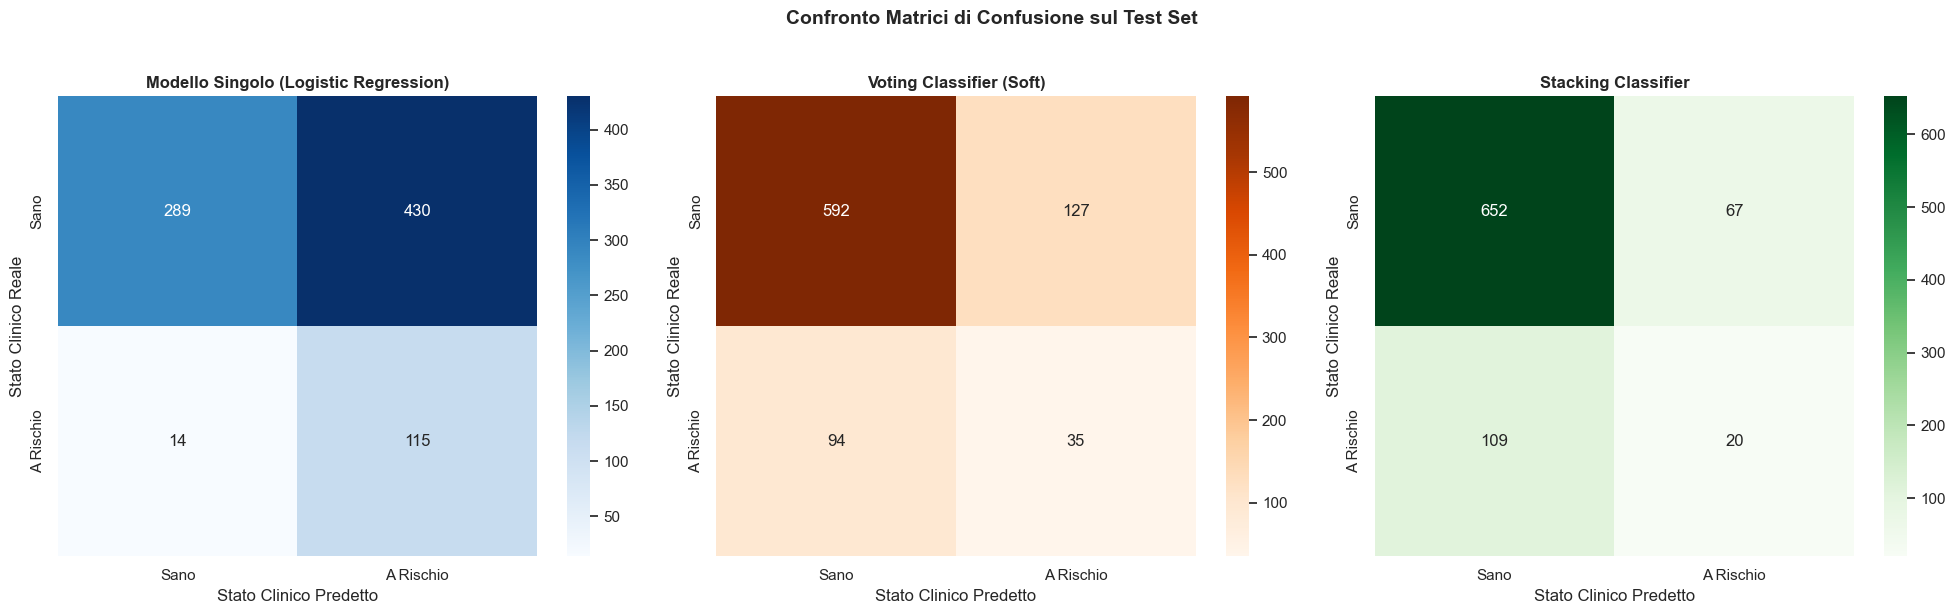

In [6]:
# Calcolo delle matrici di confusione
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, predizioni_lr)
cm_voting = confusion_matrix(y_test, predizioni_voting)
cm_stacking = confusion_matrix(y_test, predizioni_stacking)

# Plot delle matrici di confusione per un confronto visuale diretto
fig, assi = plt.subplots(1, 3, figsize=(20, 6))

# Heatmap modello singolo
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sano', 'A Rischio'], yticklabels=['Sano', 'A Rischio'], ax=assi[0])
assi[0].set_title("Modello Singolo (Logistic Regression)", fontsize=12, fontweight='bold')
assi[0].set_ylabel('Stato Clinico Reale')
assi[0].set_xlabel('Stato Clinico Predetto')

# Heatmap voting classifier
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Sano', 'A Rischio'], yticklabels=['Sano', 'A Rischio'], ax=assi[1])
assi[1].set_title("Voting Classifier (Soft)", fontsize=12, fontweight='bold')
assi[1].set_ylabel('Stato Clinico Reale')
assi[1].set_xlabel('Stato Clinico Predetto')

# Heatmap stacking classifier
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Sano', 'A Rischio'], yticklabels=['Sano', 'A Rischio'], ax=assi[2])
assi[2].set_title("Stacking Classifier", fontsize=12, fontweight='bold')
assi[2].set_ylabel('Stato Clinico Reale')
assi[2].set_xlabel('Stato Clinico Predetto')

plt.suptitle("Confronto Matrici di Confusione sul Test Set", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Discussione dei Risultati dell'Ensemble:
- **Voting Classifier (Soft)**: Ottiene un compromesso interessante tra Recall ed F1-Score, riducendo la Recall ma aumentando la precisione complessiva.
- **Stacking Classifier**: Mostra prestazioni stabili e robuste. Il meta-classificatore (Regressione Logistica) impara ad attribuire pesi ottimali alle probabilità stimate dai modelli lineari e non lineari di base.